# Mestrado em Informática
## Pós-Graduação em Data Science and Digital Transformation
### (Ambientes de) Programação para Ciência de Dados
### Projeto 1

Aluno: Miguel de Campos Rodrigues (27089)

#### OBJETIVOS
Pretende-se com este projeto utilizar o Python e as suas bibliotecas para explorar e interpretar os
dados que constam nos ficheiros incêndios_sc.csv e estados.csv
O ficheiros de dados foram obtido a partir de dados públicos disponíveis em https://queimadas.dgi.inpe.br/. O ficheiro incêndios_sc.csv apresenta informação relativa a eventos de incêndios (queimadas) detetados por satélite em municípios brasileiros pertencentes ao bioma Amazónia. O ficheiro estados.csv relaciona os municípios com os respetivos estados federais.
Devem ser dadas às resposta às questões do enunciado com base na análise efetuada com Python e nas bibliotecas adequadas. O trabalho é entregue através do PAE em formato jupyter notebook. Se precisar de entregar mais do que um ficheiro, deve submeter no PAE um único arquivo comprimido. O trabalho é sujeito a discussão em data a combinar,

#### PRIMEIRA PARTE
A primeira parte do trabalho consiste na utilização de Python e suas bibliotecas para explorar e interpretar a informação que consta nos dois ficheiros.
Realize uma análise inicial aos dados constantes em ambos os ficheiros e interprete o seu conteúdo, respondendo a questões como:

In [41]:
import io
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sys

from pandas import Timestamp

In [2]:
def is_colab():
    return "google.colab" in sys.modules

def open_csv_colab():
  uploaded = files.upload()
  if uploaded:
    (filename, content) = next(iter(uploaded))
    print('Uploaded file "{name}" with length {length} bytes'.format(
          name=fn, length=len(uploaded[filename])))

    return pd.read_csv(io.BytesIO(content))

def open_csv_local():
  app = wx.App(False)
  dialog = wx.FileDialog(
      None,
      "Choose a CSV file",
      wildcard="CSV files (*.csv)|*.csv",
      style=wx.FD_OPEN | wx.FD_FILE_MUST_EXIST
  )

  if dialog.ShowModal() == wx.ID_OK:
      path = dialog.GetPath()
      print("Selected:", path)
      df = pd.read_csv(path)
      dialog.Destroy()
      return df
  else:
      dialog.Destroy()
      print("No file selected.")
      return None

if is_colab():
  from google.colab import files
  open_csv = open_csv_colab
else:
  import wx
  open_csv = open_csv_local

##### 1. incêndios_sc.csv


In [3]:
incêndios_dt = open_csv()
incêndios_dt

Selected: D:\Mestrado\PCD\src\projeto1\incendios_sv.csv


,DataHora,Satelite,Municipi,RiscoFog
0,2018/01/01 00:04:15,GOES-16,MARCELANDIA,0.00
1,2018/01/01 00:29:09,GOES-13,MAUES,NaN
2,2018/01/01 00:29:09,GOES-13,MAUES,0.03
3,2018/01/01 00:54:55,METOP-B,TAILANDIA,0.00
4,2018/01/01 01:31:29,GOES-13,PARECIS,0.25
...,...,...,...,...
9468634,2019/01/02 04:42:00,NPP-375D,PACARAIMA,1.00
9468635,2019/01/02 04:42:00,NPP-375D,PACARAIMA,1.00
9468636,2019/01/02 04:42:00,NPP-375D,COLNIZA,0.40
9468637,2019/01/03 06:00:00,NPP-375D,NORMANDIA,1.00


Por meio a manter os dados limpos serão feitos os seguintes pontos:
- Renomear "Municipi" para "Municipio"
- Apagar duplicados distintos pelas 4 colunas
- Em duplicados pelo conjunto **(Satélite, DataHora e Municipio)**, efetuar as seguintes operações na RiscoFog:
  - Separar NaNs de valores válidos
  - Nos valores válidos, acumular médias
  - Nos valores NaNs, Fazer um "Left Anti Join" ao conjunto de válidos.
  - Juntar resultados

In [4]:
incêndios_dt = (pd.DataFrame
    .rename(incêndios_dt, {"Municipi": "Municipio"}, axis=1)
    .drop_duplicates(subset=["DataHora", "Satelite", "Municipio", "RiscoFog"]))

incêndios_dt_valores = (incêndios_dt
    .dropna(subset=["RiscoFog"])
    .groupby(["Satelite", "DataHora", "Municipio"], as_index=False)["RiscoFog"]
    .mean())

incêndios_dt_nans = (incêndios_dt[incêndios_dt["RiscoFog"].isna()]
    .merge(
        incêndios_dt_valores[["Satelite", "DataHora", "Municipio"]],
        on=["Satelite", "DataHora", "Municipio"],
        how="left",
        indicator=True)
    .query('_merge == "left_only"').drop(columns='_merge'))

incêndios_dt = (pd
    .concat([incêndios_dt_valores, incêndios_dt_nans])
    .sort_values(by="DataHora")
    .reset_index(drop=True))

incêndios_dt

,Satelite,DataHora,Municipio,RiscoFog
0,GOES-16,2018/01/01 00:04:15,MARCELANDIA,0.000
1,GOES-13,2018/01/01 00:29:09,MAUES,0.030
2,METOP-B,2018/01/01 00:54:55,TAILANDIA,0.000
3,GOES-13,2018/01/01 01:31:29,PARECIS,0.250
4,GOES-13,2018/01/01 02:27:54,CARACARAI,0.140
...,...,...,...,...
2000156,NPP-375,2022/12/31 18:10:00,MUCAJAI,0.255
2000157,NPP-375,2022/12/31 18:10:00,CANTA,0.240
2000158,NPP-375,2022/12/31 18:10:00,BONFIM,0.375
2000159,NPP-375,2022/12/31 18:10:00,AMAJARI,0.040


1.1 Qual é a dimensão do conjunto de dados?

In [5]:
incêndios_dt.shape

(2000161, 4)

**Resposta:** Antes da limpeza, a dimensão do conjunto de dados é de 9468639 linhas por 4 colunas. Após a limpeza, passa para 2000161 linhas por 4 colunas.

1.2 Qual o nome das colunas e que tipo de dados que lhe estão associados?

In [6]:
incêndios_dt.dtypes

Satelite      object
DataHora      object
Municipio     object
RiscoFog     float64
dtype: object

**Resposta:** O Pandas infere apenas o *RiscoFog* como `float64`. No entanto os restantes campos por observação apresentam ser:
- *DataHora*: `datetime`
- *Satelite*: `string`
- *Municipio*: `string`
- *RiscoFog*: `float64`

Sendo assim convertidos em:

In [7]:
incêndios_dt['DataHora'] = pd.to_datetime(incêndios_dt['DataHora'])
incêndios_dt['Satelite'] = incêndios_dt['Satelite'].astype('string')
incêndios_dt['Municipio'] = incêndios_dt['Municipio'].astype('string')
incêndios_dt.dtypes

Satelite     string[python]
DataHora     datetime64[ns]
Municipio    string[python]
RiscoFog            float64
dtype: object

1.3. Existem valores NaN? Se sim, em quantidade significativa? Em que colunas?

In [8]:
nan_cols = incêndios_dt.isnull()
total_nan_cols = nan_cols.sum()
perct_nan_cols = (total_nan_cols / incêndios_dt.shape[0] * 100).map(lambda x: f"{x:.3f}%")

print("Total de NaNs")
print(total_nan_cols)

print("\nPercentagem de NaNs")
print(perct_nan_cols)

Total de NaNs
Satelite         0
DataHora         0
Municipio        0
RiscoFog     38001
dtype: int64

Percentagem de NaNs
Satelite     0.000%
DataHora     0.000%
Municipio    0.000%
RiscoFog     1.900%
dtype: object


**Resposta:** Sim existem 38001 valores *NaN*, no campo *RiscoFog*, que correspondem a 1.9% de todo o dataset.

1.4 Qual é o intervalo temporal a que o conjunto de dados se reporta?

In [9]:
max_date = incêndios_dt['DataHora'].max()
min_date = incêndios_dt['DataHora'].min()
duration = (max_date - min_date)
d = duration.components

print(f"Data de inicio: {min_date}; Data de Fim: {max_date}; intervalo de tempo: {d.days} dias, {d.hours:02} horas, {d.minutes:02} minutos e {d.seconds:02} segundos.")

Data de inicio: 2018-01-01 00:04:15; Data de Fim: 2022-12-31 18:10:00; intervalo de tempo: 1825 dias, 18 horas, 05 minutos e 45 segundos.


**Resposta**: O intervalo temporal vai de 2018-01-01 00:04:15 até 2022-12-31 18:10:00, com um intervalo de tempo de 1825 dias, 18 horas, 05 minutos e 45 segundos.

1.5 Analise os dados da coluna “Satelite” para dar resposta às questões:

a) Quais são os satélites dominantes no dataset?

In [10]:
print("Satélites mais frequente(s):")
print(incêndios_dt['Satelite'].mode(),"\n")

print("Top 5 satelites:")
print(incêndios_dt['Satelite'].value_counts().head(5).index)

Satélites mais frequente(s):
0    GOES-16
Name: Satelite, dtype: string 

Top 5 satelites:
Index(['GOES-16', 'NOAA-20', 'NPP-375', 'AQUA_M-T', 'NPP-375D'], dtype='string', name='Satelite')


**Resposta:** Os satelites mais usados são o 'GOES-16', 'NOAA-20', 'NPP-375', 'AQUA_M-T' e 'NPP-375D', sendo o GOES-16 o mais dominante. 

b) Os satélites disponíveis foram sempre os mesmos ao longo dos anos, ou houve
alterações? Se sim, quais

In [11]:
incêndios_dt['Ano'] = incêndios_dt['DataHora'].dt.year

satelites_por_ano = pd.crosstab(
    incêndios_dt['Satelite'],
    incêndios_dt['Ano'])

satelites_por_ano

Ano,2018,2019,2020,2021,2022
Satelite,,,,,
AQUA_M-M,2239,3183,3368,2536,3873
AQUA_M-T,14364,16751,18413,15237,17626
GOES-13,248,0,0,0,0
GOES-16,134649,143940,280269,262871,348525
METOP-B,6903,9926,17288,2233,1467
METOP-C,0,39,7033,832,773
MSG-03,432,3068,3584,2354,4393
NOAA-15,2127,609,0,0,0
NOAA-15D,81,25,0,0,0


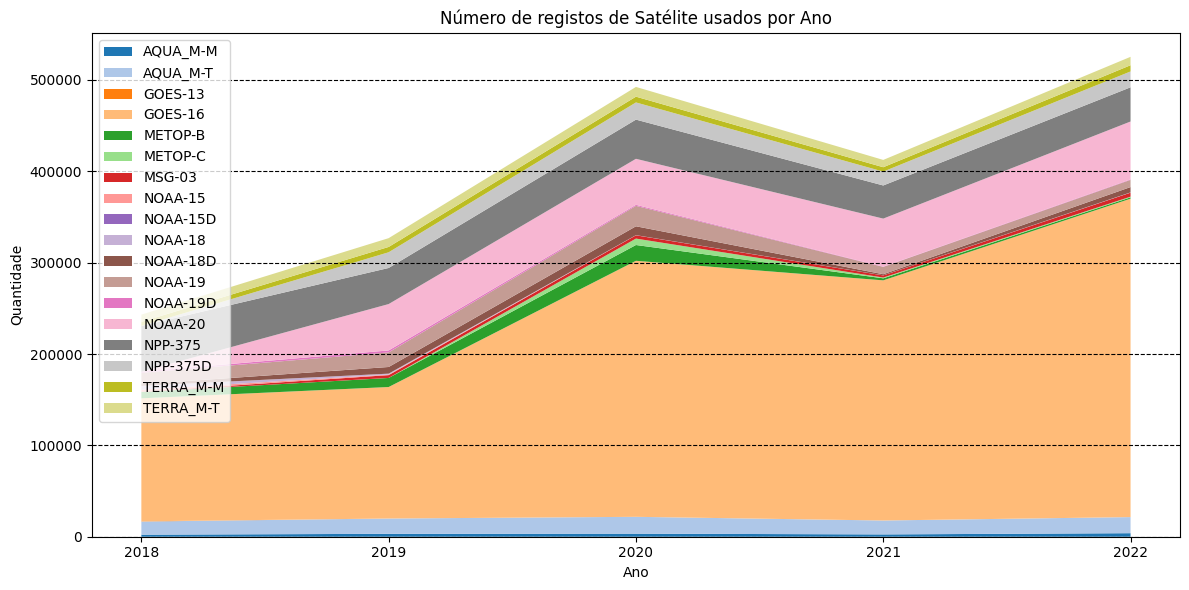

In [12]:
# StackPlot
fig, ax = plt.subplots(figsize=(12, 6))

# Color palette
num_sats = len(satelites_por_ano.index)
cmap = mpl.colormaps.get_cmap('tab20')
colors = [cmap(i) for i in range(num_sats)]

ax.stackplot(
    satelites_por_ano.columns,
    satelites_por_ano.values,
    labels=satelites_por_ano.index,
    colors=colors,
)

# Graph Characteristics
ax.set_title("Número de registos de Satélite usados por Ano")
ax.set_xticks(satelites_por_ano.columns.astype(int))
ax.set_xlabel("Ano")
ax.set_ylabel("Quantidade")
ax.legend(loc="upper left")
ax.ticklabel_format(style='plain', axis='y')
ax.grid(linestyle='--', color='0', axis = 'y')

fig.tight_layout()

# Render graphs
plt.show()

In [13]:
descricao = satelites_por_ano.describe().drop('count')
descricao.loc["total"] = satelites_por_ano.sum()
descricao.loc["cv"] = descricao.loc['std'] / descricao.loc['mean']
descricao = descricao.map(lambda x: f"{x:.5f}")
descricao

Ano,2018,2019,2020,2021,2022
mean,13507.33333,18157.38889,27355.05556,22915.38889,29184.88889
std,32425.01645,34347.65963,64749.08063,61528.42146,81322.07099
min,0.00000,0.00000,0.00000,0.00000,0.00000
25%,294.00000,1271.75000,1703.75000,451.00000,610.25000
50%,2183.00000,6566.00000,8380.00000,2445.00000,5124.00000
75%,7657.50000,16556.00000,18702.50000,13396.00000,15304.50000
max,134649.00000,143940.00000,280269.00000,262871.00000,348525.00000
total,243132.00000,326833.00000,492391.00000,412477.00000,525328.00000
cv,2.40055,1.89166,2.36699,2.68503,2.78644


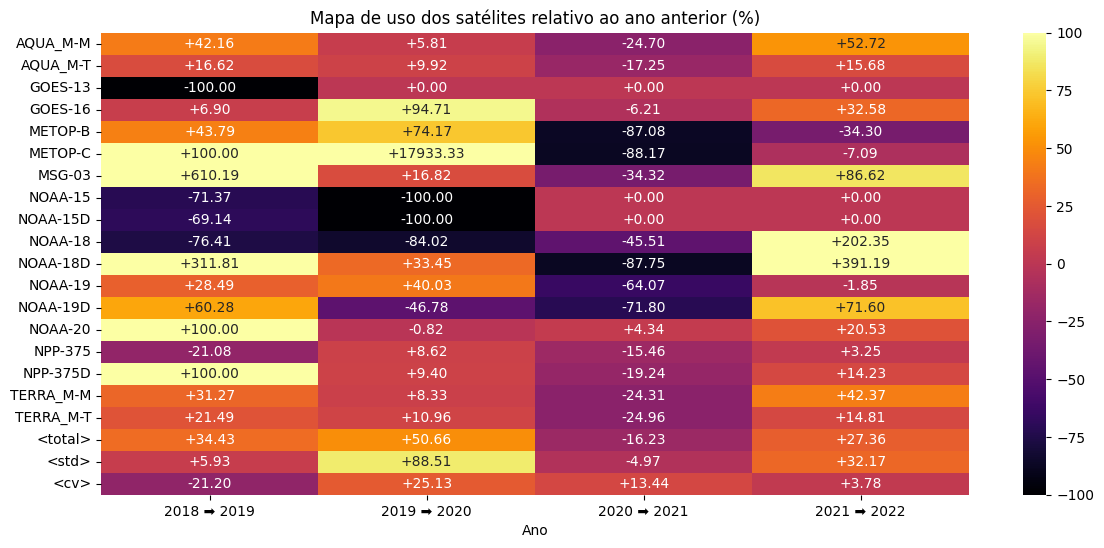

In [14]:
heatmap_relative = (pd
    .concat([satelites_por_ano, descricao.loc[['total', 'std', 'cv']]], axis=0)
    .rename(index = {
        'total': '<total>',
        'std': '<std>',
        'cv': '<cv>'
    })
    .rename(columns = {
        2019: "2018 ➡️ 2019",
        2020: "2019 ➡️ 2020",
        2021: "2020 ➡️ 2021",
        2022: "2021 ➡️ 2022"
    })
    .astype(float)
    .pct_change(axis=1)
    .fillna(0)
    .replace(np.inf, 1)
    .replace(-np.inf, -1)
    .drop(2018, axis=1) * 100
)

plt.figure(figsize=(14, 6))

sns.heatmap(heatmap_relative, annot=True, fmt="+.2f", vmin=-100, vmax=100, cmap='inferno')
plt.title('Mapa de uso dos satélites relativo ao ano anterior (%)')
plt.show()

In [15]:
heatmap_relative

Ano,2018 ➡️ 2019,2019 ➡️ 2020,2020 ➡️ 2021,2021 ➡️ 2022
AQUA_M-M,42.161679,5.812127,-24.703088,52.720820
AQUA_M-T,16.617934,9.921796,-17.248683,15.678939
GOES-13,-100.000000,0.000000,0.000000,0.000000
GOES-16,6.900163,94.712380,-6.207608,32.584043
METOP-B,43.792554,74.168849,-87.083526,-34.303627
METOP-C,100.000000,17933.333333,-88.170055,-7.091346
MSG-03,610.185185,16.818774,-34.319196,86.618522
NOAA-15,-71.368124,-100.000000,0.000000,0.000000
NOAA-15D,-69.135802,-100.000000,0.000000,0.000000
NOAA-18,-76.408025,-84.016393,-45.512821,202.352941


**Resposta:**
O uso dos satélites varia ao longo dos anos. Na tabela acima cada valor é comparado relação ao ano anterior. Assim nota-se os seguintes pontos:
- O ano 2019 e 2020 foram dois anos de maior crescimento no uso dos satélites. Em 2019, o uso cresce rapidamente, sendo o seu crescimento estabilizado em 2020. Em 2021 o uso é reduzido  
- Os satélites *TERRA_M-M*, *TERRA_M_T*, *NPP-375*, *NPP-375D*, *NOA-19*, *NOA-20*, *GOES-16*, *AQUA_M-M* e *AQUA_M-T* mantiveram um uso regular sem grandes diferenças ao longo dos anos.
- *NOAA-18D* e *MSG03* tiveram um aumento de uso considerável em 2019
- *METOP-C* tem uma discrepancia de uso enorme em 2020, em (179 vezes mais comparado com o ano anterior) o que pode ser considerado um outlier.
- *NOAA-18D*, *METOP-B* e *METOP-C* tiveram tiveram uma queda de uso significativa em 2021.
- *NOAA-18* e *NOAA-18D* tiveram um aumento de uso considerável em 2022
- Em 2021 houve uma redução de uso generalizada de todos os satélites, no entanto isto causou com que o uso dos satélites fosse mais uniforme.
- Houve um crescimento contínuo de uso do *GOES-16*, sendo este satélite o mais usado em todos os anos por mais de metade de amostras comparadas com os restantes satélites.
- *GOES-13* é apenas usado em 2018
- Os *NOAA-15* e *NOAA-15D* deixam de ser usados em 2020.
- *METOP-C*, *NOAA-20* e o *NPP-375* passam a ser usados a partir de 2019

###### Relatório de IA:
- Std: Desvio Padrão: Mede quão disperso é o uso dos satélites naquele ano.
- CV: Coeficiente de Variação, mede a dispersão relativa dos usos dos satélites em relação à média do ano. 
- Total: Acumulado de todos os satélites naquele ano.

1. 2018 ➡️ 2019
   - **total (+34.43%)** → uso global de satélites cresceu significativamente em relação a 2018.
   - **std (+5.93%)** → variação entre satélites foi pequena; aumento relativamente uniforme.
   - **cv (-21.20%)** → coeficiente negativo indica que, mesmo com crescimento médio, algumas variações individuais foram contrárias; mas a dispersão relativa foi baixa.

Resumo: crescimento sólido, uso distribuído de forma homogenea entre satélites.

2. 2019 ➡️ 2020
   - **total (+50.66%)** → aumento ainda mais intenso, expansão forte do uso de satélites.
   - **std (+88.51%)** → enorme dispersão entre satélites; alguns tiveram crescimento muito maior que outros.
   - **cv (+25.13%)** → alta variabilidade relativa; crescimento concentrado em alguns satélites dominantes.

Resumo: crescimento rápido, mas desigual; operação concentrada em poucos satélites.

3. 2020 ➡️ 2021
   - **total (-16.23%)** → queda geral de uso.
   - **std (-4.97%)** → dispersão baixa; a redução foi relativamente uniforme entre satélites.
   - **cv (+13.44%)** → dispersão relativa moderada; algumas diferenças de impacto entre satélites, mas não extremas.

Resumo: queda no uso, mas com distribuição mais equilibrada; ajuste ou consolidação operacional.

1. 2021 ➡️ 2022
   - **total (+27.36%)** → recuperação moderada do uso de satélites em relação ao ano anterior.
   - **std (+32.17%)** → dispersão intermediária; alguns satélites cresceram mais que outros.
   - **cv (+3.78%)** → dispersão relativa baixa; operação mais equilibrada, uso homogeneo.

Resumo: recuperação consistente e mais homogenea; maturidade operacional no uso dos satélites.

c) Qual é o satélite mais antigo registado no dataset? Encontra-se ainda em operação?

In [16]:
incêndios_dt

,Satelite,DataHora,Municipio,RiscoFog,Ano
0,GOES-16,2018-01-01 00:04:15,MARCELANDIA,0.000,2018
1,GOES-13,2018-01-01 00:29:09,MAUES,0.030,2018
2,METOP-B,2018-01-01 00:54:55,TAILANDIA,0.000,2018
3,GOES-13,2018-01-01 01:31:29,PARECIS,0.250,2018
4,GOES-13,2018-01-01 02:27:54,CARACARAI,0.140,2018
...,...,...,...,...,...
2000156,NPP-375,2022-12-31 18:10:00,MUCAJAI,0.255,2022
2000157,NPP-375,2022-12-31 18:10:00,CANTA,0.240,2022
2000158,NPP-375,2022-12-31 18:10:00,BONFIM,0.375,2022
2000159,NPP-375,2022-12-31 18:10:00,AMAJARI,0.040,2022


In [17]:
primeiro_uso_satelite = incêndios_dt.loc[0]
satelite_incêndios_dt = incêndios_dt[incêndios_dt['Satelite'] == primeiro_uso_satelite['Satelite']]
ultimo_uso_satelite = satelite_incêndios_dt.iloc[-1]

print(f"Satélite {primeiro_uso_satelite['Satelite']}")
print(f"\nPrimeiro uso:\n{primeiro_uso_satelite}")
print(f"\nUltimo uso:\n{ultimo_uso_satelite}")
print("\nAnos usado:", pd.unique(satelite_incêndios_dt['Ano']).tolist())

Satélite GOES-16

Primeiro uso:
Satelite                 GOES-16
DataHora     2018-01-01 00:04:15
Municipio            MARCELANDIA
RiscoFog                     0.0
Ano                         2018
Name: 0, dtype: object

Ultimo uso:
Satelite                 GOES-16
DataHora     2022-12-31 01:35:14
Municipio               ALMEIRIM
RiscoFog                    0.02
Ano                         2022
Name: 2000082, dtype: object

Anos usado: [2018, 2019, 2020, 2021, 2022]


**Resposta:** O satélite mais antigo a ser usado é o *GOES-16* e está a ser usado até à ultima data do dataset. Foi usado todos os anos do dataset, entre 1 de janeiro de 2018 a 31 de dezembro 2022.

d) Existem satélites que deixaram de operar? Quais

In [18]:
expirados = satelites_por_ano[satelites_por_ano[2022] == 0]
expirados

Ano,2018,2019,2020,2021,2022
Satelite,,,,,
GOES-13,248,0,0,0,0
NOAA-15,2127,609,0,0,0
NOAA-15D,81,25,0,0,0


**Resposta:** Sim, existem satélites que deixaram de operar, o *GOES-13*, o *NOAA-15* e o *NOAA-15D*. Abaixo fica o ultimo registo de cada satélite:

In [19]:
incêndios_dt_expirados = (incêndios_dt[incêndios_dt['Satelite']
    .isin(expirados.index)]
    .groupby("Satelite", as_index=False)
    .tail(1))

incêndios_dt_expirados

,Satelite,DataHora,Municipio,RiscoFog,Ano
1934,GOES-13,2018-01-08 15:00:11,OURILANDIA DO NORTE,0.0,2018
303326,NOAA-15,2019-07-10 22:33:26,RONDON DO PARA,0.5,2019
304218,NOAA-15D,2019-07-12 10:50:52,NOVA MARINGA,1.0,2019


##### 2. estados.csv

In [20]:
estados_dt = open_csv()
estados_dt

Selected: D:\Mestrado\PCD\src\projeto1\estados.csv


,Estado,Municipio
0,MATO GROSSO,MARCELANDIA
1,MATO GROSSO,COLNIZA
2,MATO GROSSO,JUARA
3,MATO GROSSO,COTRIGUACU
4,MATO GROSSO,PARANAITA
...,...,...
545,ACRE,BUJARI
546,ACRE,PLACIDO DE CASTRO
547,ACRE,XAPURI
548,ACRE,JORDAO


1. Qual é  o tamanho total do dataset (número de linhas e colunas)

In [21]:
estados_dt.shape

(550, 2)

**Resposta:** A dimensão do conjunto de dados é de 550 linhas por 2 colunas.

2. Quantos municípios e quantos estados estão representados no dataset?

In [22]:
print("Estados:", pd.unique(estados_dt['Estado']).size)
print("Municipios:", estados_dt['Municipio'].size)

Estados: 9
Municipios: 550


**Resposta:** Existem 9 estados e 550 municípios.

3. Existem nomes de municípios ou estados repetidos? Identifique-os.

In [23]:
print("Original:", estados_dt.shape)
print("Sem duplicados:", estados_dt.drop_duplicates().shape)

Original: (550, 2)
Sem duplicados: (550, 2)


Não existem duplicados. No entanto, se verificarmos pela distinção de cada nome de municipio:

In [24]:
municipios_ambiguos = estados_dt.groupby(['Municipio']).filter(lambda x: len(x) > 1)
municipios_ambiguos.sort_values(by="Municipio")

,Estado,Municipio
463,MARANHAO,ARAGUANA
513,TOCANTINS,ARAGUANA
277,PARA,PAU D'ARCO
496,TOCANTINS,PAU D'ARCO
330,RONDONIA,PRESIDENTE MEDICI
409,MARANHAO,PRESIDENTE MEDICI
88,MATO GROSSO,RIO BRANCO
530,ACRE,RIO BRANCO


**Resposta:** Os municípios *ARAGUANA*, *PAU D'ARCO*, *PRESIDENTE MEDICI* e *RIO BRANCO* repetem-se em dois Estados distintos.

Uma breve pesquisa a cada município confirma que:
- Existem dois munícipios de Araguana, no [Maranhão](https://pt.wikipedia.org/wiki/Araguan%C3%A3_(Maranh%C3%A3o)) e em [Tocatins](https://pt.wikipedia.org/wiki/Araguan%C3%A3_(Tocantins))
- Existem dois municípios de Pau D'Arco no [Para](https://pt.wikipedia.org/wiki/Pau-d%27Arco_(Par%C3%A1)) e em [Tocatins](https://pt.wikipedia.org/wiki/Pau-d%27Arco_(Tocantins))
- Existem dois municípios de Presidente Medici no [Maranhão](https://pt.wikipedia.org/wiki/Presidente_M%C3%A9dici_(Maranh%C3%A3o)) e na [Rodônia](https://pt.wikipedia.org/wiki/Presidente_M%C3%A9dici_(Rond%C3%B4nia))
- Existem dois municípios de Rio Branco no [Mato Grosso](https://pt.wikipedia.org/wiki/Rio_Branco_(Mato_Grosso)) e no [Acre](https://pt.wikipedia.org/wiki/Rio_Branco)

Como tal todos os valores no dataset são distintos. 

4. O dataset contém valores NaN?

In [25]:
((estados_dt.isna()) | (estados_dt == '')).sum()

Estado       0
Municipio    0
dtype: int64

**Resposta:** Não existem valores `NaN`. Também não existem células vazias `""`.

#### SEGUNDA PARTE
A segunda parte do trabalho consiste em analisar os focos de incêndio temporal e espacialmente.

1. Comece por criar um conjunto de dados (a gravação para ficheiro .csv é opcional) com as seguintes colunas: Ano, Mês, Estado, Nº de ocorrências.

In [26]:
# Adiciona coluna "Semana"
incêndios_dt["Data"] = incêndios_dt["DataHora"].dt.normalize()
incêndios_dt

,Satelite,DataHora,Municipio,RiscoFog,Ano,Data
0,GOES-16,2018-01-01 00:04:15,MARCELANDIA,0.000,2018,2018-01-01
1,GOES-13,2018-01-01 00:29:09,MAUES,0.030,2018,2018-01-01
2,METOP-B,2018-01-01 00:54:55,TAILANDIA,0.000,2018,2018-01-01
3,GOES-13,2018-01-01 01:31:29,PARECIS,0.250,2018,2018-01-01
4,GOES-13,2018-01-01 02:27:54,CARACARAI,0.140,2018,2018-01-01
...,...,...,...,...,...,...
2000156,NPP-375,2022-12-31 18:10:00,MUCAJAI,0.255,2022,2022-12-31
2000157,NPP-375,2022-12-31 18:10:00,CANTA,0.240,2022,2022-12-31
2000158,NPP-375,2022-12-31 18:10:00,BONFIM,0.375,2022,2022-12-31
2000159,NPP-375,2022-12-31 18:10:00,AMAJARI,0.040,2022,2022-12-31


In [27]:
estados_fidedignos = estados_dt.drop(municipios_ambiguos.index)
print("estados_dt (original):", estados_dt.shape)
print("municipios_ambiguos:", municipios_ambiguos.shape) 
print("estados_fidedignos:", estados_fidedignos.shape)
print("")

#Subset inflacionado
incêndios_inflacionados = pd.merge(
    incêndios_dt,
    estados_dt,
    how='inner')

#Subset fidedigno
incêndios_fidedignos = pd.merge(
    incêndios_dt,
    estados_fidedignos,
    how='inner')

print("incêndios_dt:", incêndios_dt.shape)
print("incêndios_fidedignos:", incêndios_fidedignos.shape)
print("incêndios_inflacionados:", incêndios_inflacionados.shape)

del incêndios_inflacionados #Meramente informativo. Pode-se limpar a memória.

estados_dt (original): (550, 2)
municipios_ambiguos: (8, 2)
estados_fidedignos: (542, 2)



incêndios_dt: (2000161, 6)
incêndios_fidedignos: (1986708, 7)
incêndios_inflacionados: (2013614, 7)


A tabela de incêndios não distingue os municípios acima descritos, o que vai criar ambiguidade onde a ocorrência está registada a que estado de município. Por um lado se ignorarmos estes municípios perdemos dados no dataset. Caso incluirmos, os dados para estes municípios são duplicados, inflacionando-os. Em ambas as situações temos uma difereça de 1.4% a mais ou a menos do dataset. Por outro lado não queremos perder dados que possam ser valiosos para a nossa análise, portanto ignorar está fora de questão...

O ideal seria que os dados tivessem uma referencia pardronizadas como por exemplo, os códigos IBGE de Municípios do Brasil em vez do nome do município. Estes podem ser obtidos e analisadoscom o uso da API ([GET https://servicodados.ibge.gov.br/api/v1/localidades/municipios](https://servicodados.ibge.gov.br/api/v1/localidades/municipios)) ao qual inclui dados para identificação de localizações vizinhas. A melhor abordagem será analisar o estado mais provavel para a observação de incêndios, inferindo com base em metadados das observações, nomeadamente em localizações de municípios vizinhos e datas similares com um certo grau de margem de erro, de por, exemplo 15 dias, similar ao método do videojogo "Minesweeper".

Em contexto de exercício, para não se desviar do dataset fornecido, apenas se irá inferir com base nas datas de outras amostras de dentro do mesmo estado, em datas similares.

In [28]:
# Separar subset ambíguo
ambiguos = pd.unique(municipios_ambiguos['Municipio'])

ocorrencias_ambiguas = incêndios_dt[incêndios_dt['Municipio'].isin(ambiguos)]
print(ocorrencias_ambiguas.shape)

(13453, 6)


In [29]:
# Conta a atividade de satélites por municipio, para os estados com municipios ambíguos
incêndios_fidedignos_mask = incêndios_fidedignos["Estado"].isin(municipios_ambiguos["Estado"])

counts = (
    incêndios_fidedignos[incêndios_fidedignos_mask]
        .groupby(["Estado", "Data"])
        .size()
        .reset_index(name="count")
)

# Define uma tabela de pivot Data/Estado com a contagem de ocorrências
pivot = counts.pivot_table(
    index="Data",
    columns="Estado",
    values="count",
    fill_value=0
)

#Define uma janela temporal centrada de 15 dias e obtem o estado dominante
janela = (pivot
    .rolling(window=15, center=True, min_periods=1)
    .sum()
)

estados_candidatos = (
    municipios_ambiguos
        .groupby("Municipio")["Estado"]
        .apply(list)
        .to_dict()
)

def escolhe_estado(ocorrencia):
    municipio = ocorrencia["Municipio"]
    data      = ocorrencia["Data"]

    # Estados possíveis para esse município
    candidatos = estados_candidatos.get(municipio)

    if not candidatos or data not in janela.index:
        ocorrencia["Estado"] = None
        return ocorrencia

    # Seleciona somente as colunas (Estados) válidas
    valores = janela.loc[data, candidatos]

    # Se não houver dados na janela
    if valores.isna().all():
        ocorrencia["Estado"] = None
        return ocorrencia

    # Define o estado com maior atividade
    ocorrencia["Estado"] = valores.idxmax()
    return ocorrencia


In [30]:
# Associa o estado às ocorrências ambíguas com base na data
ocorrencias_resolvidas = ocorrencias_ambiguas.apply(escolhe_estado, axis=1)

# Resultado
ocorrencias_resolvidas

,Satelite,DataHora,Municipio,RiscoFog,Ano,Data,Estado
369,NPP-375,2018-01-02 16:24:00,PRESIDENTE MEDICI,1.00,2018,2018-01-02,MARANHAO
440,AQUA_M-T,2018-01-02 17:00:00,PRESIDENTE MEDICI,1.00,2018,2018-01-02,MARANHAO
719,GOES-16,2018-01-03 15:49:23,RIO BRANCO,0.00,2018,2018-01-03,MATO GROSSO
3995,NPP-375,2018-01-18 16:24:00,PAU D'ARCO,0.00,2018,2018-01-18,PARA
5326,AQUA_M-T,2018-01-26 17:45:00,PRESIDENTE MEDICI,0.39,2018,2018-01-26,MARANHAO
...,...,...,...,...,...,...,...
1999514,NOAA-20,2022-12-27 05:57:00,RIO BRANCO,0.00,2022,2022-12-27,MATO GROSSO
1999518,NPP-375D,2022-12-27 06:46:00,RIO BRANCO,0.00,2022,2022-12-27,MATO GROSSO
1999647,NOAA-20,2022-12-27 18:30:00,RIO BRANCO,0.00,2022,2022-12-27,MATO GROSSO
1999729,NOAA-20,2022-12-28 05:35:00,RIO BRANCO,0.00,2022,2022-12-28,MATO GROSSO


In [31]:
# Reagrupar dataset
print(incêndios_dt.shape)

incêndios_dt = pd.concat([incêndios_fidedignos, ocorrencias_resolvidas])
print(incêndios_dt.shape)

incêndios_dt["Mês"] = incêndios_dt["DataHora"].dt.month
incêndios_confirmados_mask = incêndios_dt["RiscoFog"] > 0
ocorrencias_data_estado = (incêndios_dt[incêndios_confirmados_mask]
    .groupby(["Ano", "Mês", "Estado"])
    .size()
    .to_frame("Nº de ocorrências"))

ocorrencias_data_estado.to_csv("Ocorrências por ano mês e estado.csv")
ocorrencias_data_estado

(2000161, 6)
(2000161, 7)


Nº de ocorrências
Ano  Mês Estado                        
2018 1   ACRE                        16
         AMAPA                       39
         AMAZONAS                    95
         MARANHAO                   486
         MATO GROSSO                654
...                                 ...
2022 12  MATO GROSSO                303
         PARA                      2657
         RONDONIA                   311
         RORAIMA                    532
         TOCANTINS                   23

[519 rows x 1 columns]

2. Evolução anual dos incêndios

a) Como evoluiu o número total de incêndios ao longo dos anos?

In [32]:
incêndios_por_ano = ocorrencias_data_estado.groupby("Ano")["Nº de ocorrências"].sum()
incêndios_por_ano

Ano
2018    226717
2019    296357
2020    443156
2021    362111
2022    458658
Name: Nº de ocorrências, dtype: int64

In [33]:
relatividade_incêndios = (incêndios_por_ano
    .pct_change()
    .drop(2018) * 100
)
relatividade_incêndios

Ano
2019    30.716708
2020    49.534514
2021   -18.288142
2022    26.662267
Name: Nº de ocorrências, dtype: float64

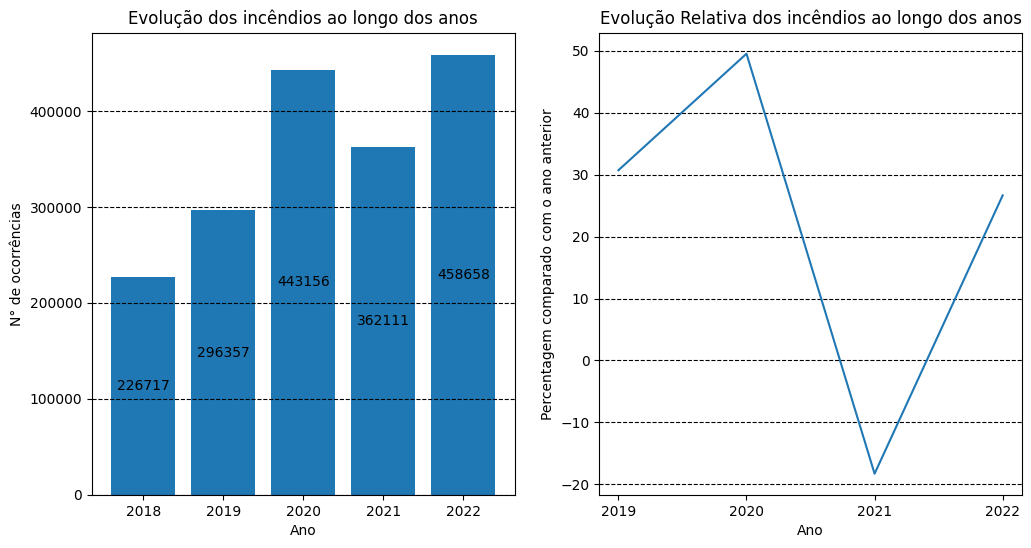

In [34]:
# StackPlot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

bar = ax1.bar(
    incêndios_por_ano.index,
    incêndios_por_ano.values
)

# Graph Characteristics
ax1.set_title("Evolução dos incêndios ao longo dos anos")
ax1.set_xticks(incêndios_por_ano.index.astype(int))
ax1.set_xlabel("Ano")
ax1.set_ylabel("N° de ocorrências")
ax1.ticklabel_format(style='plain', axis='y')
ax1.grid(linestyle='--', color='0', axis = 'y')
ax1.bar_label(bar, label_type='center')

ax2.plot(
    relatividade_incêndios.index,
    relatividade_incêndios.values
)
ax2.set_title("Evolução Relativa dos incêndios ao longo dos anos")
ax2.set_xticks(relatividade_incêndios.index.astype(int))
ax2.set_xlabel("Ano")
ax2.set_ylabel("Percentagem comparado com o ano anterior")
ax2.ticklabel_format(style='plain', axis='y')
ax2.grid(linestyle='--', color='0', axis = 'y')

# Render graphs
plt.show()

**Resposta:** O número total de incêndios aumentou ao longo dos anos:
- Em 2018 houve 226717 ocorrências 
- Em 2019 houve 296357 ocorrências, o que aumentou 31% comparado com o ano anterior.
- Em 2020 houve 443156 ocorrências, o que aumentou 50% comparado com o ano anterior.
- Em 2021 houve 362111 ocorrências, o que diminuiu 18% comparado com o ano anterior.
- Em 2022 houve 458658 ocorrências, o que aumentou 27% comparado com o ano anterior.

b) Observa-se alguma tendência significativa?

**Resposta:** Observa-se um aumento não linear, dois picos de ocorrências em 2020 e 2022. Em 2021 observa-se uma queda acentuada no número de ocorrências.

c) Em que anos se registaram o menor e o maior número de ocorrências?

**Resposta:** O ano com menor número de ocorrências é 2018 e o com maior número é 2022.

3. Distribuição mensal e análise por estado

a) Como se distribui o número de incêndios ao longo dos meses do ano (usar os valores médios no período representado)?

In [35]:
distribuicao_mensal = ocorrencias_data_estado.groupby(["Ano", "Mês"])
# distribuicao_mensal.describe()

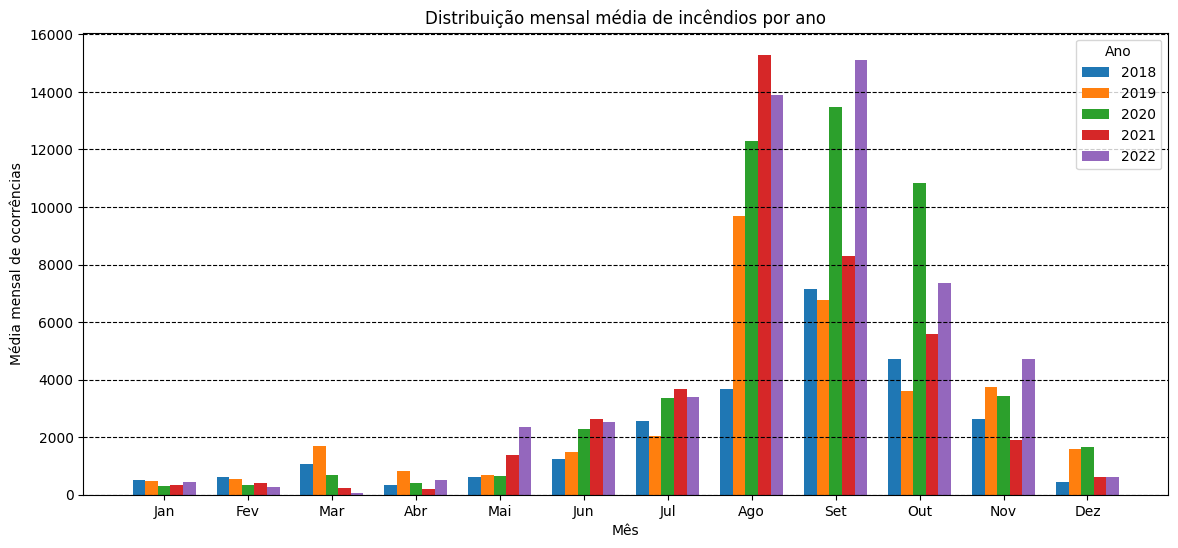

In [36]:
df_plot = distribuicao_mensal.mean().reset_index()
anos = df_plot["Ano"].unique()

fig, ax = plt.subplots(figsize=(14, 6))

for i, ano in enumerate(anos):
    medias = df_plot[df_plot["Ano"] == ano]["Nº de ocorrências"]
    meses = df_plot[df_plot["Ano"] == ano]["Mês"]

    # Barras deslocadas
    ax.bar(meses + i * 0.15 - 0.3, medias, width=0.15, label=str(ano))

ax.set_xlabel("Mês")
ax.set_ylabel("Média mensal de ocorrências")
ax.set_title("Distribuição mensal média de incêndios por ano")
meses_extenso = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", 
                 "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

ax.set_xticks(np.arange(1, 13))
ax.set_xticklabels(meses_extenso)

ax.ticklabel_format(style='plain', axis='y')
ax.grid(linestyle='--', color='0', axis = 'y')

ax.legend(title="Ano")
plt.show()


**Resposta:** A distribuição descreve que existe um pico de ocorrências entre Agosto e Outubro em todos os anos. A amplitude é mais sólida no mês de agosto. um aumento consideravel de incêndios em 2022 no entanto 2021 foi o pior ano a com o maior número de ocorrências registadas.

b) Para cada estado, determine: o número total de incêndios, o valor médio e o desvio-padrão das ocorrências.

In [37]:
valores_estados = (ocorrencias_data_estado
    .groupby(["Estado"])["Nº de ocorrências"]
    .agg(["sum", "mean", "std"])
    .rename({
        "sum": "Total",
        "mean": "Média",
        "std": "Desvio Padrão"
    }, axis=1))

valores_estados

,Total,Média,Desvio Padrão
Estado,,,
ACRE,57188,969.288136,1740.815337
AMAPA,14930,317.659574,510.060963
AMAZONAS,201249,3354.150000,7092.327613
MARANHAO,133627,2303.913793,3140.180022
MATO GROSSO,477340,7955.666667,9574.712784
PARA,592057,9867.616667,13882.686941
RONDONIA,226534,3775.566667,6019.591341
RORAIMA,66860,1114.333333,2298.418068
TOCANTINS,17214,312.981818,455.341650


c) Que estados apresentam o maior e o menor número de incêndios?

In [38]:
valores_ordenados = valores_estados.sort_values(by="Total")
extremos = pd.concat([valores_ordenados.head(1), valores_ordenados.tail(1)])
extremos.index

Index(['AMAPA', 'PARA'], dtype='object', name='Estado')

**Resposta:** Os estados mais extremos são o PARA, com maior número de incêndios e o AMAPA, com o menor numero de incêndios.

4. Análise temporal dos estados extremos: considerando os estados identificados na questão anterior, analise a evolução anual do número de incêndios em cada um deles.

In [39]:
estados_extremos = ocorrencias_data_estado.reset_index()

estados_extremos_amapa_mask = estados_extremos["Estado"] == 'AMAPA'
estados_extremos_amapa = estados_extremos[estados_extremos_amapa_mask]

estados_extremos_para_mask = estados_extremos["Estado"] == 'PARA'
estados_extremos_para = estados_extremos[estados_extremos_para_mask]

extremos = {
    "AMAPA": estados_extremos_amapa,
    "PARA": estados_extremos_para,
}

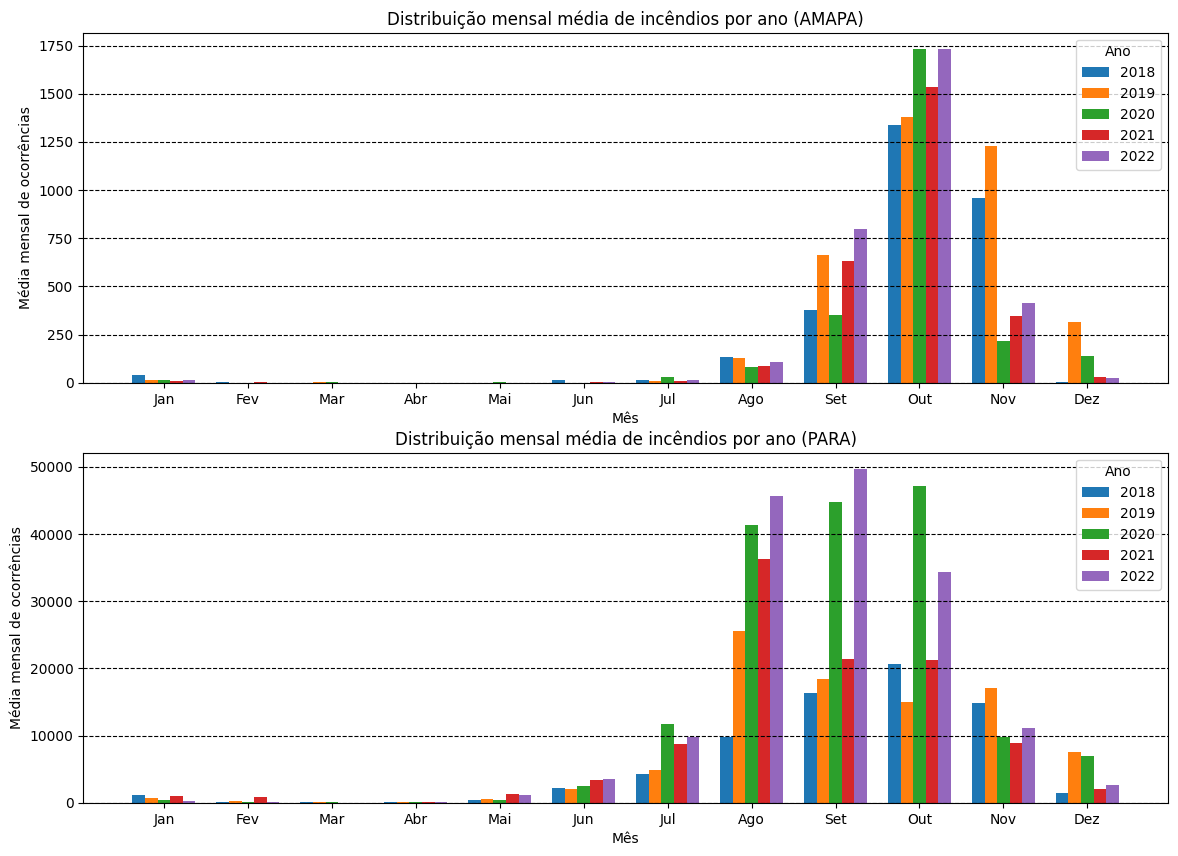

In [40]:
fig, axs = plt.subplots(2, 1, figsize=(14, 10))
for (estado, dados), ax in zip(extremos.items(), axs):
    anos = dados["Ano"].unique()

    for i, ano in enumerate(anos):
        medias = dados[dados["Ano"] == ano]["Nº de ocorrências"]
        meses = dados[dados["Ano"] == ano]["Mês"]

        # Barras deslocadas
        ax.bar(meses + i * 0.15 - 0.3, medias, width=0.15, label=str(ano))

    ax.set_xlabel("Mês")
    ax.set_ylabel("Média mensal de ocorrências")
    ax.set_title("Distribuição mensal média de incêndios por ano (" + estado + ")")
    meses_extenso = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", 
                    "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

    ax.set_xticks(np.arange(1, 13))
    ax.set_xticklabels(meses_extenso)

    ax.ticklabel_format(style='plain', axis='y')
    ax.grid(linestyle='--', color='0', axis = 'y')

    ax.legend(title="Ano")
    
plt.show()

**Resposta**:
- Para além da diferença de escala de incêndios em ambos os Estados, existe uma diferença de tendência do periodo da época de incêndios.
- Enquanto no Pará os incêndios são maioritariamente entre Julho e Dezembro, a época de incendios no Amapá situa-se entre Agosto e Dezembro.
- Os incendios no Amapá começam mais tarde que no Pará, em Julho, comparado em Maio.
- Enquanto os incendios no Pará lavram de forma contínua entre Agosto e Outubro, No Amapá têm a tendencia a lavrar com mais frequencia em Agosto.
- No Pará em 2020 e 2022 foram anos muito fustigados por um enormes vagas de Incêndios em Agost, Setembro e Outubro, ao qual fez extrapolar a escala esperada com a vaga de incêndios em mais intensa apenas em agosto. Enquanto no Pará tem tido na maior parte dos anos um aumento progressivo de incendios, de forma uniforme ao longo dos meses.